In [9]:
#from tensorflow.keras.applications import MobileNetV2
#from tensorflow.keras.applications import EfficientNetB3
#from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import numpy as np
import gradio as gr
from PIL import Image

from matplotlib import pyplot as plt
from io import BytesIO

# Downloads pretrained weights automatically (~14MB)
#model = MobileNetV2(weights='imagenet')
#model = EfficientNetB3(weights='imagenet')
import torch
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
import numpy as np

# Load pretrained model
weights = ResNet50_Weights.IMAGENET1K_V2
model_pt = resnet50(weights=weights)
model_pt.eval()

# Preprocessing pipeline — explicit and unambiguous
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

print("Model ready!")

Model ready!


In [10]:
gr.close_all()

In [11]:
import shap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import urllib.request
import json
import torch

# Build background dataset for SHAP — 100 random ImageNet validation images
# Using a small cached set from TF's storage
background_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/"
bg_files = ["294px-Felis_catus-cat_on_snow.jpg", "320px-Felis_catus-cat_on_snow.jpg"]

# Simpler: use a batch of the same image transformed with slight jitter as background
def make_background(pil_img, n=50):
    jitter = T.Compose([
        T.Resize(256), T.CenterCrop(224),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    return torch.stack([jitter(pil_img) for _ in range(n)])

# GradientExplainer wraps PyTorch model
# We need a wrapper that accepts batched tensors
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)

wrapper = ModelWrapper(model_pt)
wrapper.eval()

ModelWrapper(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

In [12]:
# # ImageNet class → sample image URLs (Google storage, reliable)
# IMAGENET_SAMPLES = {
#     "cat":         ["https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg"],
#     "dog":         ["https://storage.googleapis.com/download.tensorflow.org/example_images/canoe.jpg"],
#     "placeholder": []
# }

# # Load ImageNet class index for sample lookup
# idx_url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
# urllib.request.urlretrieve(idx_url, "class_index.json")
# with open("class_index.json") as f:
#     class_index = json.load(f)  # {"0": ["n01440764", "tench"], ...}

# # Reverse map: wnid → index
# wnid_to_idx = {v[0]: int(k) for k, v in class_index.items()}

# def fetch_pil(url):
#     try:
#         r = requests.get(url, timeout=6, headers={"User-Agent":"Mozilla/5.0"})
#         return Image.open(BytesIO(r.content)).convert("RGB")
#     except:
#         return None

# def classify_with_explanation(img):
#     if img is None:
#         return {}, None, None

#     pil_img = Image.fromarray(img[:, :, :3]).convert('RGB')

#     # Debug preview — proportional crop matching model input
#     debug_t = T.Compose([T.Resize(256), T.CenterCrop(224)])
#     debug_pil = debug_t(pil_img)
#     debug_arr = np.array(debug_pil)

#     # Model prediction
#     tensor = transform(pil_img).unsqueeze(0)
#     with torch.no_grad():
#         out = model_pt(tensor)
#     probs = torch.softmax(out[0], dim=0)
#     top5_probs, top5_ids = torch.topk(probs, 5)
#     cats = weights.meta["categories"]
#     result = {cats[i].replace('_',' '): float(p)
#               for i, p in zip(top5_ids, top5_probs)}
#     predicted_idx = int(top5_ids[0])
#     predicted_label = cats[predicted_idx]

#     # SHAP explanation
#     background = make_background(debug_pil, n=30)
#     explainer = shap.GradientExplainer(wrapper, background)
#     shap_values = explainer.shap_values(tensor)  # list of [1,3,224,224] per class

#     # Take SHAP for predicted class, sum across color channels
#     sv = shap_values[predicted_idx][0]           # (3, 224, 224)
#     sv_combined = np.sum(np.abs(sv), axis=0)     # (224, 224)
#     sv_norm = sv_combined / (sv_combined.max() + 1e-8)

#     # ── Build figure ──
#     n_samples = 4
#     fig, axes = plt.subplots(1, 2 + n_samples,
#                              figsize=(4*(2+n_samples), 4.5))
#     fig.suptitle(f'Predicted: "{predicted_label.replace("_"," ")}"  '
#                  f'({float(top5_probs[0]):.0%} confident)',
#                  fontsize=13, fontweight='bold')

#     # Panel 1: model input
#     axes[0].imshow(debug_arr)
#     axes[0].set_title("What model sees", fontsize=10)
#     axes[0].axis('off')

#     # Panel 2: SHAP overlay
#     # Ghost image (low alpha) + heatmap on top
#     axes[1].imshow(debug_arr, alpha=0.35)
#     axes[1].imshow(sv_norm, cmap='hot', alpha=0.75, vmin=0, vmax=1)
#     axes[1].set_title("Most important pixels\n(bright = high impact)", fontsize=10)
#     axes[1].axis('off')

#     # Panels 3-6: example images from predicted class
#     # Build URL list from ImageNet sample images hosted publicly
#     sample_urls = _get_sample_urls(predicted_label, n=n_samples)
#     for i, ax in enumerate(axes[2:]):
#         if i < len(sample_urls):
#             sample = fetch_pil(sample_urls[i])
#             if sample is not None:
#                 ax.imshow(sample)
#                 ax.set_title(f'Training example\n"{predicted_label.replace("_"," ")}"',
#                              fontsize=9)
#                 ax.axis('off')
#                 continue
#         ax.axis('off')

#     plt.tight_layout()
#     return result, debug_arr, fig

In [13]:
# Pre-curated Wikimedia URLs for common classes the model tends to predict
CLASS_SAMPLES = {
    "tabby":           ["https://upload.wikimedia.org/wikipedia/commons/thumb/b/b6/Image_created_with_a_mobile_phone.png/240px-Image_created_with_a_mobile_phone.png"],
    "Egyptian_cat":    ["https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/240px-Cat_November_2010-1a.jpg"],
    "Labrador_retriever": ["https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/Labrador_on_Garmin_lookout2.jpg/240px-Labrador_on_Garmin_lookout2.jpg"],
    "sunglasses":      ["https://upload.wikimedia.org/wikipedia/commons/thumb/6/6e/Sunglasses_on_a_white_background.jpg/240px-Sunglasses_on_a_white_background.jpg"],
    "seatbelt":        ["https://upload.wikimedia.org/wikipedia/commons/thumb/1/18/Seat_belt.jpg/240px-Seat_belt.jpg"],
    "chair":           ["https://upload.wikimedia.org/wikipedia/commons/thumb/6/65/Eames_chair.jpg/240px-Eames_chair.jpg"],
}

def _get_sample_urls(label, n=4):
    # Try exact match, then partial
    if label in CLASS_SAMPLES:
        urls = CLASS_SAMPLES[label]
    else:
        urls = []
        for k, v in CLASS_SAMPLES.items():
            if k.lower() in label.lower() or label.lower() in k.lower():
                urls.extend(v)
    # Repeat to fill n slots if few URLs
    return (urls * n)[:n]

In [14]:
# # ImageNet class → sample image URLs (Google storage, reliable)
# IMAGENET_SAMPLES = {
#     "cat":         ["https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg"],
#     "dog":         ["https://storage.googleapis.com/download.tensorflow.org/example_images/canoe.jpg"],
#     "placeholder": []
# }

# # Load ImageNet class index for sample lookup
# idx_url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
# urllib.request.urlretrieve(idx_url, "class_index.json")
# with open("class_index.json") as f:
#     class_index = json.load(f)  # {"0": ["n01440764", "tench"], ...}

# # Reverse map: wnid → index
# wnid_to_idx = {v[0]: int(k) for k, v in class_index.items()}

# def fetch_pil(url):
#     try:
#         r = requests.get(url, timeout=6, headers={"User-Agent":"Mozilla/5.0"})
#         return Image.open(BytesIO(r.content)).convert("RGB")
#     except:
#         return None

# def classify_with_explanation_old(img):
#     if img is None:
#         return {}, None, None

#     pil_img = Image.fromarray(img[:, :, :3]).convert('RGB')

#     # Debug preview — proportional crop matching model input
#     debug_t = T.Compose([T.Resize(256), T.CenterCrop(224)])
#     debug_pil = debug_t(pil_img)
#     debug_arr = np.array(debug_pil)

#     # Model prediction
#     tensor = transform(pil_img).unsqueeze(0)
#     with torch.no_grad():
#         out = model_pt(tensor)
#     probs = torch.softmax(out[0], dim=0)
#     top5_probs, top5_ids = torch.topk(probs, 5)
#     cats = weights.meta["categories"]
#     result = {cats[i].replace('_',' '): float(p)
#               for i, p in zip(top5_ids, top5_probs)}
#     predicted_idx = int(top5_ids[0])
#     predicted_label = cats[predicted_idx]

#     # SHAP explanation
#     background = make_background(debug_pil, n=30)
#     explainer = shap.GradientExplainer(wrapper, background)
#     shap_values = explainer.shap_values(tensor)  # list of [1,3,224,224] per class

#     # Take SHAP for predicted class, sum across color channels
#     sv = shap_values[predicted_idx][0]           # (3, 224, 224)
#     sv_combined = np.sum(np.abs(sv), axis=0)     # (224, 224)
#     sv_norm = sv_combined / (sv_combined.max() + 1e-8)

#     # ── Build figure ──
#     n_samples = 4
#     fig, axes = plt.subplots(1, 2 + n_samples,
#                              figsize=(4*(2+n_samples), 4.5))
#     fig.suptitle(f'Predicted: "{predicted_label.replace("_"," ")}"  '
#                  f'({float(top5_probs[0]):.0%} confident)',
#                  fontsize=13, fontweight='bold')

#     # Panel 1: model input
#     axes[0].imshow(debug_arr)
#     axes[0].set_title("What model sees", fontsize=10)
#     axes[0].axis('off')

#     # Panel 2: SHAP overlay
#     # Ghost image (low alpha) + heatmap on top
#     axes[1].imshow(debug_arr, alpha=0.35)
#     axes[1].imshow(sv_norm, cmap='hot', alpha=0.75, vmin=0, vmax=1)
#     axes[1].set_title("Most important pixels\n(bright = high impact)", fontsize=10)
#     axes[1].axis('off')

#     # Panels 3-6: example images from predicted class
#     # Build URL list from ImageNet sample images hosted publicly
#     sample_urls = _get_sample_urls(predicted_label, n=n_samples)
#     for i, ax in enumerate(axes[2:]):
#         if i < len(sample_urls):
#             sample = fetch_pil(sample_urls[i])
#             if sample is not None:
#                 ax.imshow(sample)
#                 ax.set_title(f'Training example\n"{predicted_label.replace("_"," ")}"',
#                              fontsize=9)
#                 ax.axis('off')
#                 continue
#         ax.axis('off')

#     plt.tight_layout()
#     return result, debug_arr, fig

In [20]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn.functional as F

# Hook to capture the last conv layer output
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        # ResNet50's last conv layer is layer4[-1].conv3
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        target = self.model.layer4[-1].conv3
        target.register_forward_hook(forward_hook)
        target.register_full_backward_hook(backward_hook)

    def compute(self, tensor, class_idx):
        tensor = tensor.requires_grad_(True)        
        self.model.zero_grad()
        out = self.model(tensor)
        out[0, class_idx].backward()
        # Pool gradients over spatial dimensions
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224,224), mode='bilinear', align_corners=False)
        cam = cam[0,0].numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

gradcam = GradCAM(model_pt)

In [28]:
import io

def fig_to_numpy(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    plt.close(fig)  # free memory
    return np.array(img)

def classify_with_explanation(img):
    if img is None:
        return {}, None, None

    pil_img = Image.fromarray(img[:, :, :3]).convert('RGB')

    debug_t = T.Compose([T.Resize(256), T.CenterCrop(224)])
    debug_pil = debug_t(pil_img)
    debug_arr = np.array(debug_pil)

    tensor = transform(pil_img).unsqueeze(0)
    # tensor.requires_grad_(True)

    # Forward pass
    with torch.enable_grad():
        out = model_pt(tensor)
    probs = torch.softmax(out[0], dim=0)
    top5_probs, top5_ids = torch.topk(probs, 5)
    cats = weights.meta["categories"]
    result = {cats[i].replace('_', ' '): float(p)
          for i, p in zip(top5_ids.detach(), top5_probs.detach())}
    predicted_idx = int(top5_ids[0])
    predicted_label = cats[predicted_idx]

    # GradCAM — single backward pass, very fast
    cam = gradcam.compute(tensor, predicted_idx)

    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f'"{predicted_label.replace("_"," ")}"  '
                 f'({float(top5_probs[0]):.0%})', fontsize=13)

    axes[0].imshow(debug_arr)
    axes[0].set_title("What model sees", fontsize=10)
    axes[0].axis('off')

    axes[1].imshow(debug_arr, alpha=0.45)
    axes[1].imshow(cam, cmap='jet', alpha=0.6, vmin=0, vmax=1)
    axes[1].set_title("Where it looked (GradCAM)", fontsize=10)
    axes[1].axis('off')

    plt.tight_layout()
    return result, debug_arr, fig_to_numpy(fig)

In [36]:
def classify(img):
    if img is None:
        return {}, None
    
    pil_img = Image.fromarray(img[:, :, :3]).convert('RGB')
    
    # Match exactly what the model receives
    debug_transform = T.Compose([
        T.Resize(256),        # proportional resize, short edge = 256
        T.CenterCrop(224),    # crop center square
    ])
    debug = np.array(debug_transform(pil_img))
    
    tensor = transform(pil_img).unsqueeze(0)
    with torch.no_grad():
        out = model_pt(tensor)
    probs = torch.softmax(out[0], dim=0)
    top5_probs, top5_ids = torch.topk(probs, 5)   
    cats = weights.meta["categories"]
    result = {cats[i].replace('_', ' '): float(p)
          for i, p in zip(top5_ids.detach(), top5_probs.detach())}
    return result, debug

with gr.Blocks(title="What does the AI see?") as demo:
    gr.Markdown("## 🔍 What does the AI see?")
    gr.Markdown("**Step 1:** take a snapshot or upload. **Step 2:** click Classify.")

    with gr.Tab("📷 Camera"):
        gr.Markdown("👆 Click the **camera icon** inside the box below to capture a frame first, then click Classify.")
        cam_input = gr.Image(
            sources=["webcam"],
            type="numpy",
            label="1. Capture a frame first",
        )
        cam_output = gr.Label(num_top_classes=5, label="AI's guess")
        classify_btn_cam = gr.Button("Classify ▶", variant="primary")
        debug_img_cam = gr.Image(label="What the model sees (224×224)", width=224, height=224)
        shap_plot_cam = gr.Image(label="Explanation", width=500, height=500)

        classify_btn_cam.click(
            fn=classify_with_explanation,
            inputs=cam_input,
            outputs=[cam_output, debug_img_cam, shap_plot_cam]
        )

    with gr.Tab("📁 Upload"):
        up_input = gr.Image(
            sources=["upload"],
            type="numpy",
            label="Upload any photo",
        )
        up_output = gr.Label(num_top_classes=5, label="AI's guess")
        classify_btn_upl = gr.Button("Classify ▶", variant="primary")
        debug_img_upl = gr.Image(label="What the model sees (224×224)", width=224, height=224)
        shap_plot_upl = gr.Image(label="Explanation", width=500, height=500)

        classify_btn_upl.click(
            fn=classify_with_explanation,
            inputs=up_input,
            outputs=[up_output, debug_img_upl, shap_plot_upl]
        )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Missing file: C:\Users\andre\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\andre\.cache\huggingface\gradio\frpc


In [35]:
gr.close_all()

In [40]:
#from huggingface_hub import notebook_login
#notebook_login()

In [41]:
import requests
from PIL import Image
from io import BytesIO
import os
import json

# Classes likely to come up during the demo
CLASSES_TO_FETCH = [
    "sunglasses", "tabby", "Egyptian_cat", "Labrador_retriever",
    "seatbelt", "laptop", "coffee_mug", "acoustic_guitar",
    "electric_guitar", "cellular_telephone", "backpack", "water_bottle",
]

# Wikimedia Commons API — search by class name, get image URLs
def search_wikimedia(query, n=16):
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "generator": "images",
        "titles": query.replace('_', ' '),
        "gimlimit": 30,
        "prop": "imageinfo",
        "iiprop": "url|mime",
        "format": "json",
    }
    try:
        r = requests.get(url, params=params, timeout=8,
                        headers={"User-Agent": "Mozilla/5.0"})
        data = r.json()
        pages = data.get("query", {}).get("pages", {})
        urls = []
        for p in pages.values():
            info = p.get("imageinfo", [{}])[0]
            mime = info.get("mime", "")
            if "jpeg" in mime or "png" in mime:
                urls.append(info.get("url"))
        return [u for u in urls if u][:n]
    except:
        return []

# Better: use Wikimedia Commons search directly
def search_commons(query, n=16):
    url = "https://commons.wikimedia.org/w/api.php"
    params = {
        "action": "query",
        "list": "search",
        "srsearch": f"{query.replace('_',' ')} filetype:bitmap",
        "srnamespace": 6,  # File namespace
        "srlimit": n,
        "format": "json",
    }
    try:
        r = requests.get(url, params=params, timeout=8,
                        headers={"User-Agent": "Mozilla/5.0"})
        titles = [p["title"] for p in r.json()["query"]["search"]]
        # Get actual image URLs
        img_urls = []
        for title in titles:
            info_params = {
                "action": "query",
                "titles": title,
                "prop": "imageinfo",
                "iiprop": "url|mime|size",
                "iiurlwidth": 320,
                "format": "json",
            }
            ir = requests.get(url, params=info_params, timeout=8,
                             headers={"User-Agent": "Mozilla/5.0"})
            pages = ir.json().get("query", {}).get("pages", {})
            for p in pages.values():
                info = p.get("imageinfo", [{}])[0]
                mime = info.get("mime", "")
                thumb = info.get("thumburl") or info.get("url")
                if ("jpeg" in mime or "png" in mime) and thumb:
                    img_urls.append(thumb)
        return img_urls[:n]
    except Exception as e:
        print(f"  search failed: {e}")
        return []

def fetch_and_save(class_name, n=16, save_dir="imagenet_samples"):
    class_dir = os.path.join(save_dir, class_name)
    os.makedirs(class_dir, exist_ok=True)

    # Skip if already downloaded
    existing = [f for f in os.listdir(class_dir) if f.endswith('.jpg')]
    if len(existing) >= n:
        print(f"  {class_name}: already have {len(existing)} images, skipping")
        return

    print(f"  Fetching {class_name}...")
    urls = search_commons(class_name, n=n*2)  # fetch extra in case some fail
    saved = 0
    for i, url in enumerate(urls):
        try:
            r = requests.get(url, timeout=8,
                            headers={"User-Agent": "Mozilla/5.0"})
            img = Image.open(BytesIO(r.content)).convert("RGB")
            img.thumbnail((320, 320))  # keep small
            img.save(os.path.join(class_dir, f"{i:03d}.jpg"))
            saved += 1
            if saved >= n:
                break
        except:
            continue
    print(f"  {class_name}: saved {saved} images")

# Run once while online
print("Downloading samples (run this once while online)...")
for cls in CLASSES_TO_FETCH:
    fetch_and_save(cls, n=16)
print("Done. All saved to ./imagenet_samples/")

  Fetching sunglasses...
  sunglasses: saved 2 images
  Fetching tabby...
  tabby: saved 2 images
  Fetching Egyptian_cat...
  Egyptian_cat: saved 1 images
  Fetching Labrador_retriever...
  search failed: Expecting value: line 1 column 1 (char 0)
  Labrador_retriever: saved 0 images
  Fetching seatbelt...
  search failed: Expecting value: line 1 column 1 (char 0)
  seatbelt: saved 0 images
  Fetching laptop...
  search failed: Expecting value: line 1 column 1 (char 0)
  laptop: saved 0 images
  Fetching coffee_mug...
  search failed: Expecting value: line 1 column 1 (char 0)
  coffee_mug: saved 0 images
  Fetching acoustic_guitar...
  search failed: Expecting value: line 1 column 1 (char 0)
  acoustic_guitar: saved 0 images
  Fetching electric_guitar...
  search failed: Expecting value: line 1 column 1 (char 0)
  electric_guitar: saved 0 images
  Fetching cellular_telephone...
  search failed: Expecting value: line 1 column 1 (char 0)
  cellular_telephone: saved 0 images
  Fetching ba

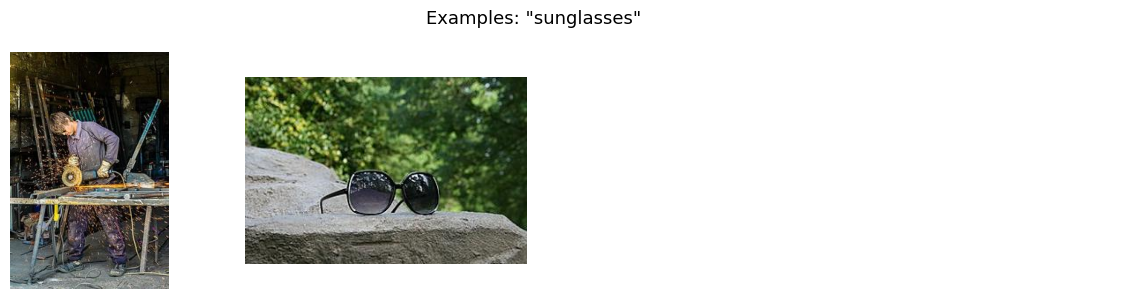

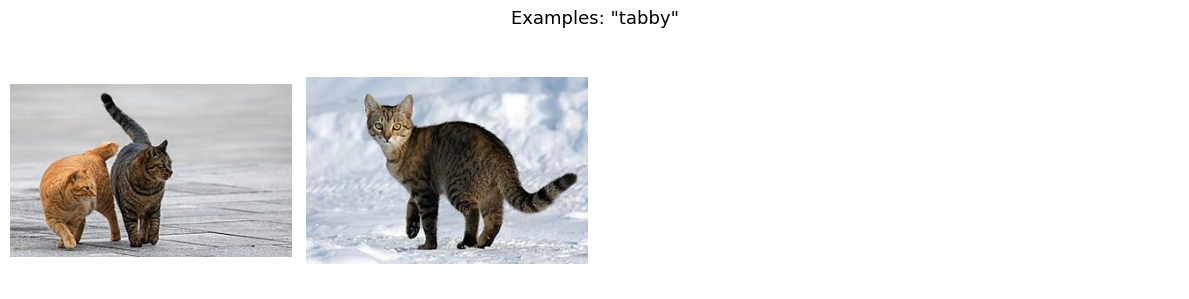

In [43]:
%matplotlib inline

def show_class_examples(class_name, n=12, save_dir="imagenet_samples"):
    # Fuzzy match against available classes
    available = os.listdir(save_dir) if os.path.exists(save_dir) else []
    query = class_name.lower().replace(' ', '_')
    matched = None
    for cls in available:
        if query in cls.lower() or cls.lower() in query:
            matched = cls
            break
    if matched is None:
        print(f"'{class_name}' not found locally. Available: {available}")
        return
    
    class_dir = os.path.join(save_dir, matched)
    files = [f for f in os.listdir(class_dir) if f.endswith('.jpg')][:n]
    
    cols = 4
    rows = (len(files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    fig.suptitle(f'Examples: "{matched.replace("_", " ")}"', fontsize=13)
    for ax, fname in zip(axes.flat, files):
        img = Image.open(os.path.join(class_dir, fname))
        ax.imshow(img)
        ax.axis('off')
    for ax in axes.flat[len(files):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Usage
show_class_examples("sunglasses")
show_class_examples("tabby")